In [19]:
import pandas as pd
import seaborn as sns

weatherPrediction = pd.read_csv("weatherHistory.csv")

In [20]:
weatherPrediction.shape
weatherPrediction.info()
weatherPrediction.describe()
weatherPrediction.head(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.


In [ ]:
weatherPrediction.drop(columns=['Formatted Date', 'Daily Summary', 'Apparent Temperature (C)'], inplace=True)

<Axes: xlabel='Temperature (C)', ylabel='Humidity'>

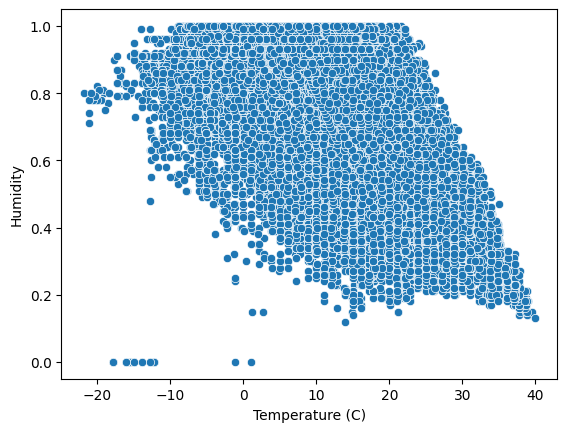

In [22]:
sns.scatterplot(x=weatherPrediction['Temperature (C)'], y=weatherPrediction['Humidity'])

In [23]:
from sklearn.model_selection import train_test_split
x = weatherPrediction.drop(columns=['Temperature (C)'])
y = weatherPrediction['Temperature (C)']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

y_pred = model.predict(x_test)

print("R2 Score: ", r2_score(y_test, y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Mean Absolute Percentage Error: ", mean_absolute_percentage_error(y_test, y_pred))

R2 Score:  0.44690129226893516
Mean Absolute Error:  5.6751290711123685
Mean Squared Error:  7.1016090878207025
Mean Absolute Percentage Error:  103269302804629.69


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

model = LinearRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

print("R2 Score: ", r2_score(y_test, y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", np.sqrt(mean_squared_error(y_test, y_pred)))  

R2 Score:  0.4469240503010936
Mean Absolute Error:  5.6763267761900496
Mean Squared Error:  7.101462983419915
